In [2]:
%load_ext autoreload
%autoreload 2

import sys
import featuregraph as fg
import numpy as np

print("Python:", sys.executable)
print("FeatureGraph:", fg.__file__)

Python: /usr/local/bin/python
FeatureGraph: /workspaces/featuregraph/src/featuregraph/__init__.py


In [3]:
bidmc = fg.datasets.bidmc(
    subject=1,
)

In [4]:
bidmc = fg.oscillation.waves.add_wave_primitives(bidmc, ['respiration'])
bidmc = fg.oscillation.waves.add_wave_id(bidmc, ['respiration'], 'subject')
bidmc = fg.oscillation.waves.add_wave_features(bidmc, ['respiration'], 'respiration_wave_id')

In [5]:
bidmc['respiration_wave_id']

0          0
1          0
2          0
3          0
4          0
        ... 
59996    554
59997    554
59998    554
59999    554
60000    554
Name: respiration_wave_id, Length: 60001, dtype: int64

In [6]:
from featuregraph.utils.plot import plot

In [7]:
baseline = (
    bidmc.groupby('respiration_wave_id')['respiration']
         .transform('min')
)

bidmc['respiration_above_baseline'] = (
    bidmc['respiration'] - baseline
)

bidmc['auc_above_baseline'] = (
    bidmc.groupby('respiration_wave_id')
         ['respiration_above_baseline']
         .cumsum()
)

bidmc['auc_at_peak'] = np.where(bidmc['exit_respiration_rising'] == 1, bidmc['auc_above_baseline'], 0)
bidmc['is_auc_above_baseline'] = bidmc['auc_above_baseline'] > 0

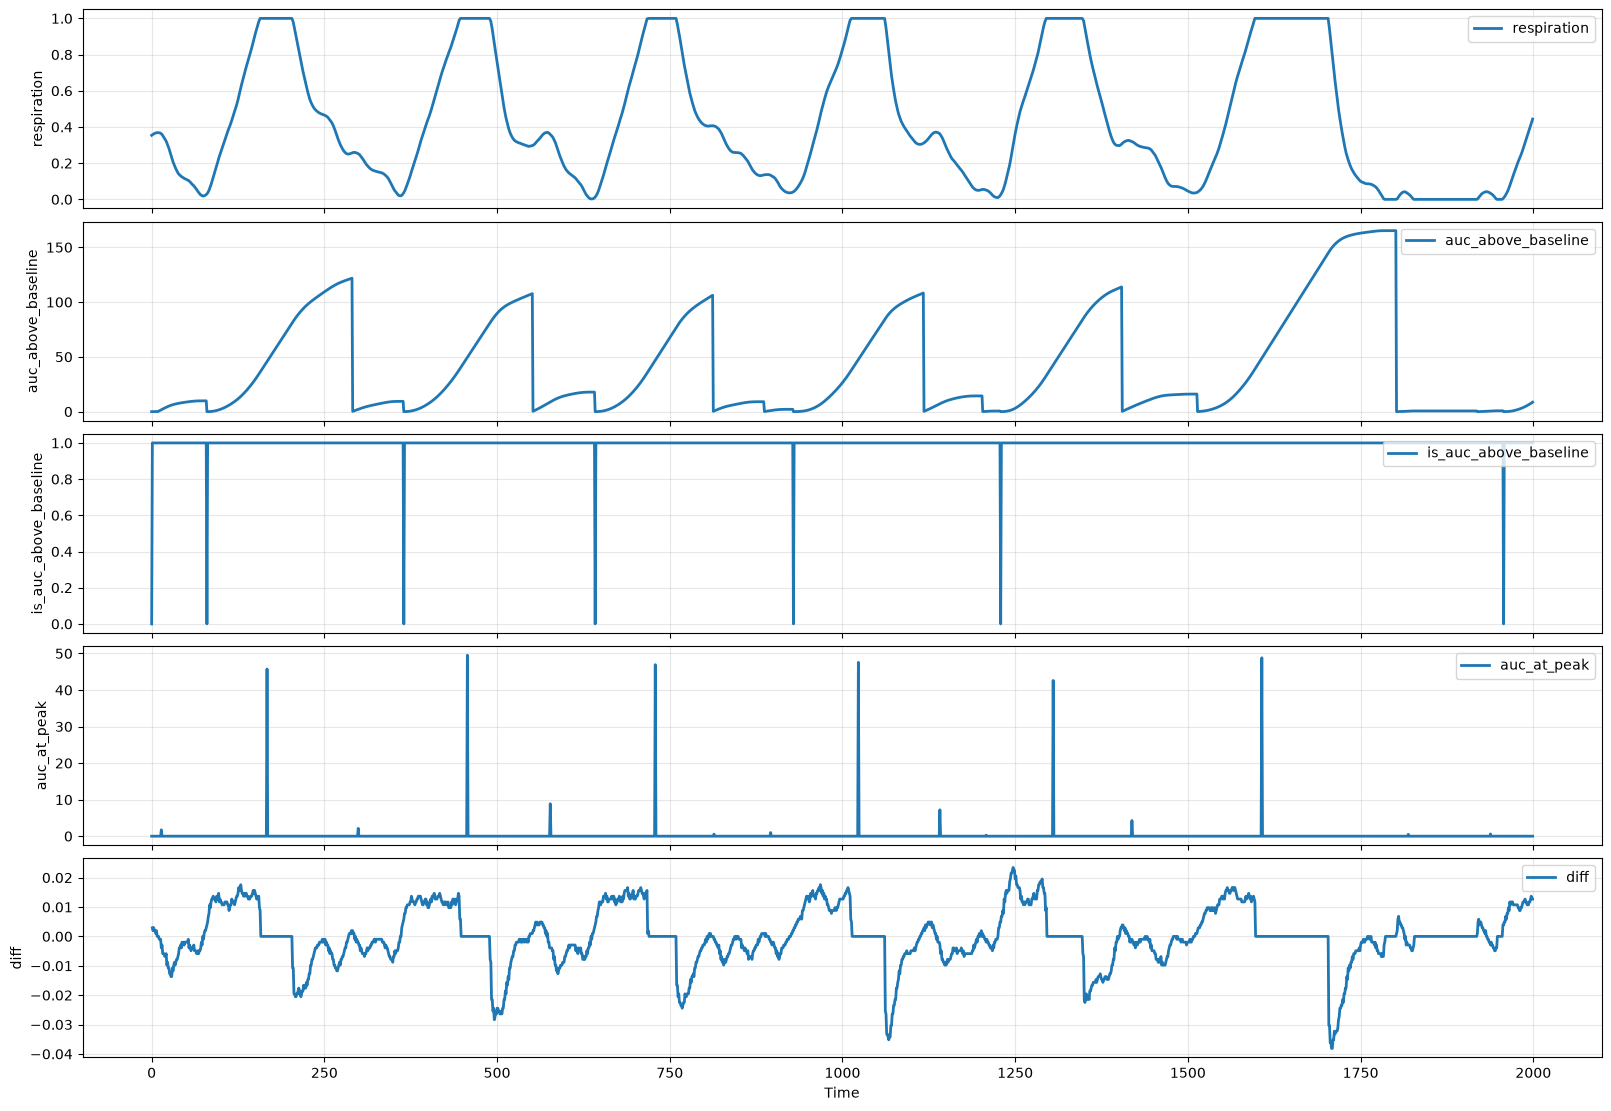

In [8]:
bidmc['diff'] = bidmc['respiration'].diff()
fig, axes = plot(bidmc[:2000],[['respiration'], 
                               ['auc_above_baseline'], 
                               ['is_auc_above_baseline'],
                               ['auc_at_peak'], 
                               ['diff']])

In [ ]:
summarydf = bidmc.groupby('respiration_wave_id').agg(
    total_auc=('auc_above_baseline', 'max'),
    auc_mean=('auc_above_baseline', 'mean'),
    auc_at_peak=('auc_at_peak', 'max'),
    time_to_max_auc=('is_auc_above_baseline', 'sum') 
)

In [11]:
summarydf

,total_auc,auc_mean,auc_at_peak,time_to_max_auc
respiration_wave_id,,,,
0,0.093840,0.037636,0.000000,9
1,9.866038,7.233548,1.737045,70
2,121.809414,60.993803,45.742933,210
3,9.390079,6.333423,2.138800,74
4,107.700804,51.933221,49.525838,186
...,...,...,...,...
550,11.942353,7.854384,8.267878,95
551,3.753673,1.559279,2.547406,56
552,98.348120,46.223115,54.841690,201


<!-- Possible feature	Meaning
total_auc	Total accumulated quantity
accumulation_rate	Average accumulation per unit time
peak_accumulation_rate	Maximum instantaneous contribution
accumulation_before_peak	Quantity accumulated before peak
accumulation_after_peak	Quantity accumulated after peak
accumulation_symmetry	Fraction accumulated before vs. after peak
normalized_auc	AUC normalized by duration or amplitude
accumulation_efficiency	AUC relative to theoretical maximum
centroid_time	Center of mass of accumulated quantity
half_accumulation_time	Time when 50% of total accumulation has occurred -->

In [ ]:
# Possible feature	Meaning
# total_auc	Total accumulated quantity
# accumulation_rate	Average accumulation per unit time
# peak_accumulation_rate	Maximum instantaneous contribution
# accumulation_before_peak	Quantity accumulated before peak
# accumulation_after_peak	Quantity accumulated after peak
# accumulation_symmetry	Fraction accumulated before vs. after peak
# normalized_auc	AUC normalized by duration or amplitude
# accumulation_efficiency	AUC relative to theoretical maximum
# centroid_time	Center of mass of accumulated quantity
# half_accumulation_time	Time when 50% of total accumulation has occurred
# time to max auc
# percentiles/quantiles